In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

%matplotlib inline

print("All libraries imported successfully!")

✓ All libraries imported successfully!


In [ ]:
DATA_DIR = "../data/train"
IMAGES_DIR = os.path.join(DATA_DIR, "images")
LABELS_DIR = os.path.join(DATA_DIR, "labels")
TARGETS_DIR = os.path.join(DATA_DIR, "targets")

if os.path.exists(DATA_DIR):
    print(f"Data directory found: {DATA_DIR}")
    
    # Count files
    if os.path.exists(IMAGES_DIR):
        num_images = len([f for f in os.listdir(IMAGES_DIR) if f.endswith('.png')])
        print(f"Found {num_images} images")
    
    if os.path.exists(LABELS_DIR):
        num_labels = len([f for f in os.listdir(LABELS_DIR) if f.endswith('.json')])
        print(f"Found {num_labels} label files")
else:
    print(f"Data directory not found yet: {DATA_DIR}")
    print("   (This is normal if download is still in progress)")

✓ Data directory found: ../data/train
✓ Found 5598 images
✓ Found 5598 label files


In [ ]:
def get_image_pairs(images_dir):
    """
    Find all pre/post image pairs in the directory.
    Returns a list of tuples: (disaster_name, image_id, pre_path, post_path)
    """
    pairs = []
    
    # Get all pre-disaster images
    pre_images = [f for f in os.listdir(images_dir) if f.endswith('_pre_disaster.png')]
    
    for pre_img in pre_images:
        # Extract the base name (everything before '_pre_disaster.png')
        base_name = pre_img.replace('_pre_disaster.png', '')
        
        # Build paths
        pre_path = os.path.join(images_dir, pre_img)
        post_path = os.path.join(images_dir, base_name + '_post_disaster.png')
        
        # Check if post image exists
        if os.path.exists(post_path):
            # Extract disaster name and ID from filename
            parts = base_name.split('_')
            disaster_name = parts[0]
            image_id = parts[1] if len(parts) > 1 else "unknown"
            
            pairs.append((disaster_name, image_id, pre_path, post_path))
    
    return pairs

print("Image pair loading function defined")

✓ Image pair loading function defined


In [ ]:
def visualize_image_pair(pre_path, post_path, title=""):
    """
    Display pre and post disaster images side by side.
    """
    # Load images
    pre_img = Image.open(pre_path)
    post_img = Image.open(post_path)
    
    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    
    # Display pre-disaster image
    axes[0].imshow(pre_img)
    axes[0].set_title('Before Disaster', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # Display post-disaster image
    axes[1].imshow(post_img)
    axes[1].set_title('After Disaster', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    if title:
        fig.suptitle(title, fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print image info
    print(f"Image size: {pre_img.size}")
    print(f"Image mode: {pre_img.mode}")

print("Visualization function defined")

✓ Visualization function defined


In [ ]:
def load_labels(label_path):
    """
    Load and parse a label JSON file.
    Returns the parsed JSON data.
    """
    with open(label_path, 'r') as f:
        data = json.load(f)
    return data

def print_label_info(label_data):
    """
    Print information about the label data.
    """
    print("=" * 50)
    print("LABEL FILE STRUCTURE")
    print("=" * 50)
    
    # Metadata
    if 'metadata' in label_data:
        print("\nMetadata:")
        for key, value in label_data['metadata'].items():
            print(f"  {key}: {value}")
    
    # Features (buildings)
    if 'features' in label_data and 'xy' in label_data['features']:
        buildings = label_data['features']['xy']
        print(f"\nNumber of buildings: {len(buildings)}")
        
        # Analyze damage types (for post-disaster images)
        damage_counts = {}
        for building in buildings:
            if 'properties' in building and 'subtype' in building['properties']:
                subtype = building['properties']['subtype']
                damage_counts[subtype] = damage_counts.get(subtype, 0) + 1
        
        if damage_counts:
            print("\nDamage distribution:")
            for damage_type, count in sorted(damage_counts.items()):
                percentage = (count / len(buildings)) * 100
                print(f"  {damage_type}: {count} ({percentage:.1f}%)")

print("Label loading functions defined")

✓ Label loading functions defined


Loading image pairs...
✓ Found 2799 image pairs

Disaster types in dataset:
  - guatemala-volcano: 18 images
  - hurricane-florence: 319 images
  - hurricane-harvey: 319 images
  - hurricane-matthew: 238 images
  - hurricane-michael: 343 images
  - mexico-earthquake: 121 images
  - midwest-flooding: 279 images
  - palu-tsunami: 113 images
  - santa-rosa-wildfire: 226 images
  - socal-fire: 823 images

📸 Visualizing: guatemala-volcano (ID: 00000000)


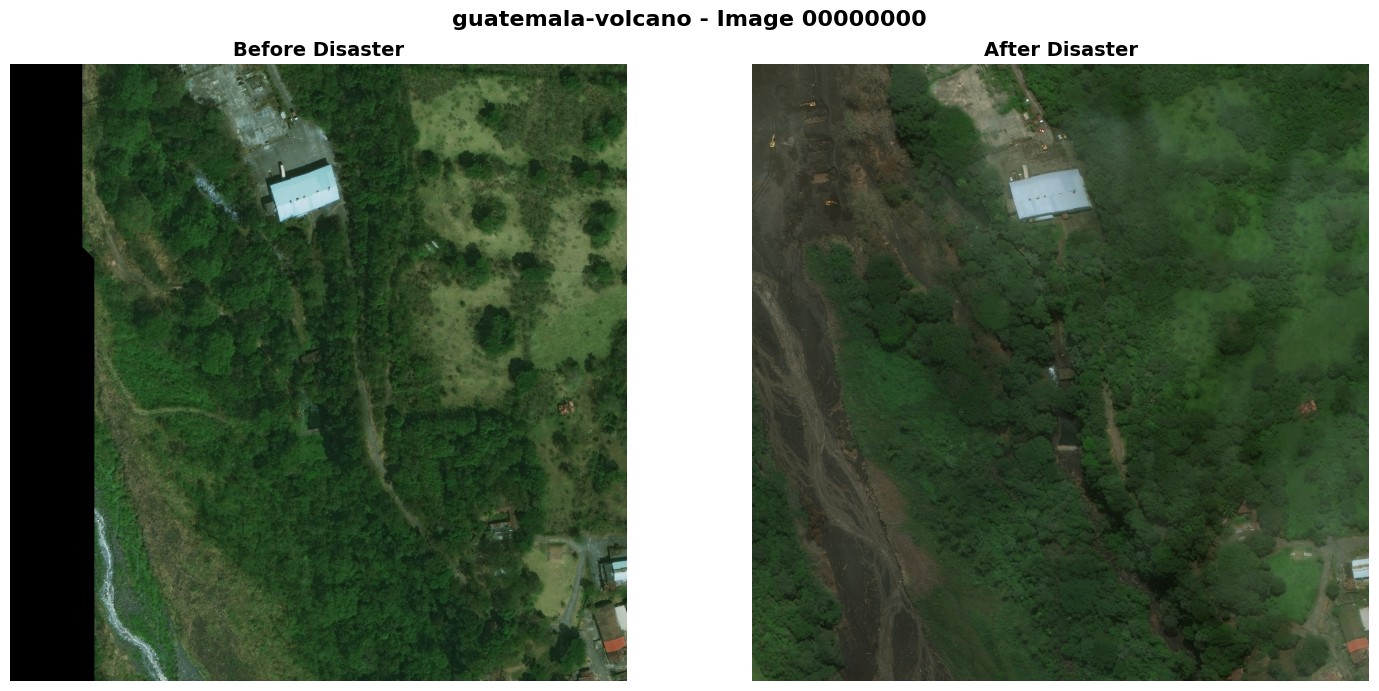

Image size: (1024, 1024)
Image mode: RGB
LABEL FILE STRUCTURE

Metadata:
  sensor: WORLDVIEW03_VNIR
  provider_asset_type: WORLDVIEW03_VNIR
  gsd: 1.4085245
  capture_date: 2018-06-22T16:55:40.000Z
  off_nadir_angle: 21.97336
  pan_resolution: 0.35173947
  sun_azimuth: 58.571484
  sun_elevation: 71.182274
  target_azimuth: 314.29373
  disaster: guatemala-volcano
  disaster_type: volcano
  catalog_id: 104001003E575F00
  original_width: 1024
  original_height: 1024
  width: 1024
  height: 1024
  id: MjU0NzE2NA.73QhG8U-LJLGkyNS0FB24X8vQS8
  img_name: guatemala-volcano_00000000_post_disaster.png

Number of buildings: 10

Damage distribution:
  no-damage: 10 (100.0%)


In [ ]:
# Get all image pairs
print("Loading image pairs...")
pairs = get_image_pairs(IMAGES_DIR)
print(f"Found {len(pairs)} image pairs")

# Show some examples of disaster types
print("\nDisaster types in dataset:")
unique_disasters = set([pair[0] for pair in pairs])
for disaster in sorted(unique_disasters):
    count = len([p for p in pairs if p[0] == disaster])
    print(f"  - {disaster}: {count} images")

# Visualize the first image pair
if len(pairs) > 0:
    disaster_name, image_id, pre_path, post_path = pairs[0]
    print(f"\n📸 Visualizing: {disaster_name} (ID: {image_id})")
    visualize_image_pair(pre_path, post_path, title=f"{disaster_name} - Image {image_id}")
    
    # Load and show label info
    label_filename = f"{disaster_name}_{image_id}_post_disaster.json"
    label_path = os.path.join(LABELS_DIR, label_filename)
    
    if os.path.exists(label_path):
        label_data = load_labels(label_path)
        print_label_info(label_data)

📸 Visualizing: hurricane-florence (ID: 00000059)


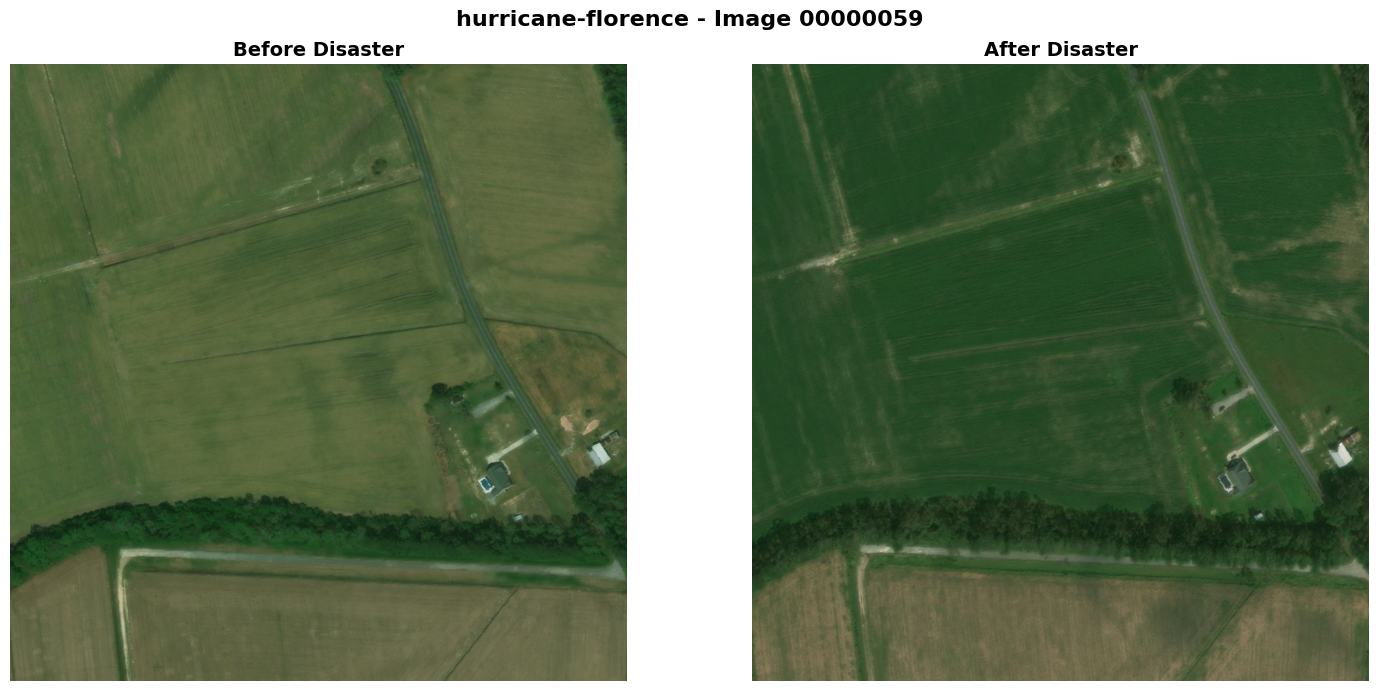

Image size: (1024, 1024)
Image mode: RGB
LABEL FILE STRUCTURE

Metadata:
  sensor: GEOEYE01
  provider_asset_type: GEOEYE01
  gsd: 2.0916247
  capture_date: 2018-09-20T16:04:41.000Z
  off_nadir_angle: 28.017313
  pan_resolution: 0.52282465
  sun_azimuth: 153.94543
  sun_elevation: 53.722378
  target_azimuth: 190.82309
  disaster: hurricane-florence
  disaster_type: flooding
  catalog_id: 1050010012411600
  original_width: 1024
  original_height: 1024
  width: 1024
  height: 1024
  id: MjU0NjY3Mg.ZH4ikZKkSvdr9iWCIhJMft5cBuk
  img_name: hurricane-florence_00000059_post_disaster.png

Number of buildings: 4

Damage distribution:
  no-damage: 4 (100.0%)


In [ ]:
hurricane_pairs = [p for p in pairs if 'hurricane' in p[0]]

if len(hurricane_pairs) > 0:
    # Pick a random hurricane image
    import random
    disaster_name, image_id, pre_path, post_path = random.choice(hurricane_pairs)
    
    print(f"📸 Visualizing: {disaster_name} (ID: {image_id})")
    visualize_image_pair(pre_path, post_path, title=f"{disaster_name} - Image {image_id}")
    
    # Load label info
    label_filename = f"{disaster_name}_{image_id}_post_disaster.json"
    label_path = os.path.join(LABELS_DIR, label_filename)
    
    if os.path.exists(label_path):
        label_data = load_labels(label_path)
        print_label_info(label_data)

In [ ]:
import random

def explore_disaster_type(disaster_keyword):
    """
    Show a random example from a specific disaster type
    """
    # Find all pairs matching the disaster type
    matching_pairs = [p for p in pairs if disaster_keyword.lower() in p[0].lower()]
    
    if len(matching_pairs) == 0:
        print(f"No images found for '{disaster_keyword}'")
        return
    
    # Pick a random one
    disaster_name, image_id, pre_path, post_path = random.choice(matching_pairs)
    
    print(f"Showing: {disaster_name} (ID: {image_id})")
    print(f"   Total {disaster_keyword} images: {len(matching_pairs)}")
    print()
    
    # Visualize
    visualize_image_pair(pre_path, post_path, title=f"{disaster_name} - Image {image_id}")
    
    # Show damage info
    label_filename = f"{disaster_name}_{image_id}_post_disaster.json"
    label_path = os.path.join(LABELS_DIR, label_filename)
    
    if os.path.exists(label_path):
        label_data = load_labels(label_path)
        print_label_info(label_data)

print("Exploration function ready!")
print("\nAvailable disaster types:")
print("  - hurricane")
print("  - fire")
print("  - flood")
print("  - earthquake")
print("  - tsunami")
print("  - volcano")

✓ Exploration function ready!

Available disaster types:
  - hurricane
  - fire
  - flood
  - earthquake
  - tsunami
  - volcano


📸 Showing: mexico-earthquake (ID: 00000191)
   Total earthquake images: 121



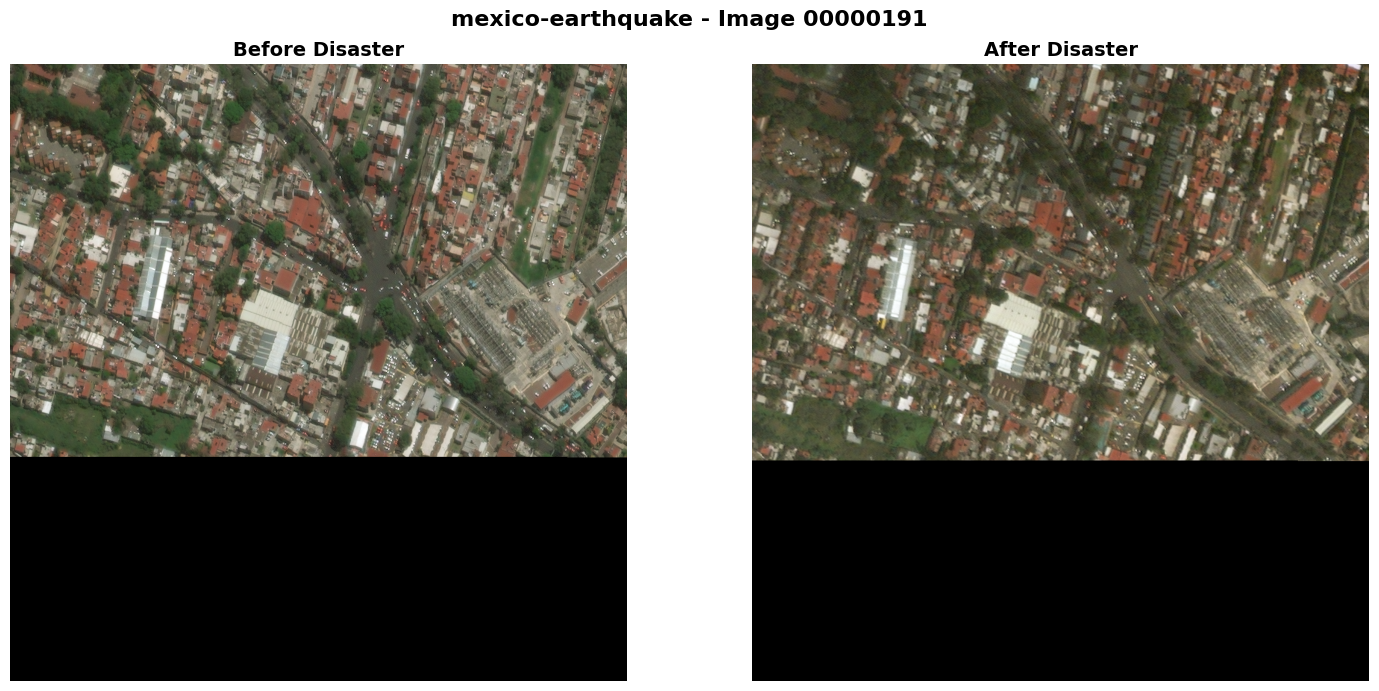

Image size: (1024, 1024)
Image mode: RGB
LABEL FILE STRUCTURE

Metadata:
  sensor: WORLDVIEW02
  provider_asset_type: WORLDVIEW02
  gsd: 2.6503215
  capture_date: 2017-09-20T17:46:11.000Z
  off_nadir_angle: 34.376244
  pan_resolution: 0.6604087
  sun_azimuth: 148.53
  sun_elevation: 68.674
  target_azimuth: 105.50913
  disaster: mexico-earthquake
  disaster_type: earthquake
  catalog_id: 1030010072469D00
  original_width: 1024
  original_height: 1024
  width: 1024
  height: 1024
  id: MjU4NjAyMw.OUTNVa-XgBpacL-t12UY3j_3qy4
  img_name: mexico-earthquake_00000191_post_disaster.png

Number of buildings: 359

Damage distribution:
  no-damage: 359 (100.0%)


In [ ]:
explore_disaster_type("earthquake")

🔍 Searching for heavily damaged areas...
✓ Found 36 examples with 50%+ damage

Showing the most damaged area:
📸 socal-fire - 100.0% buildings damaged


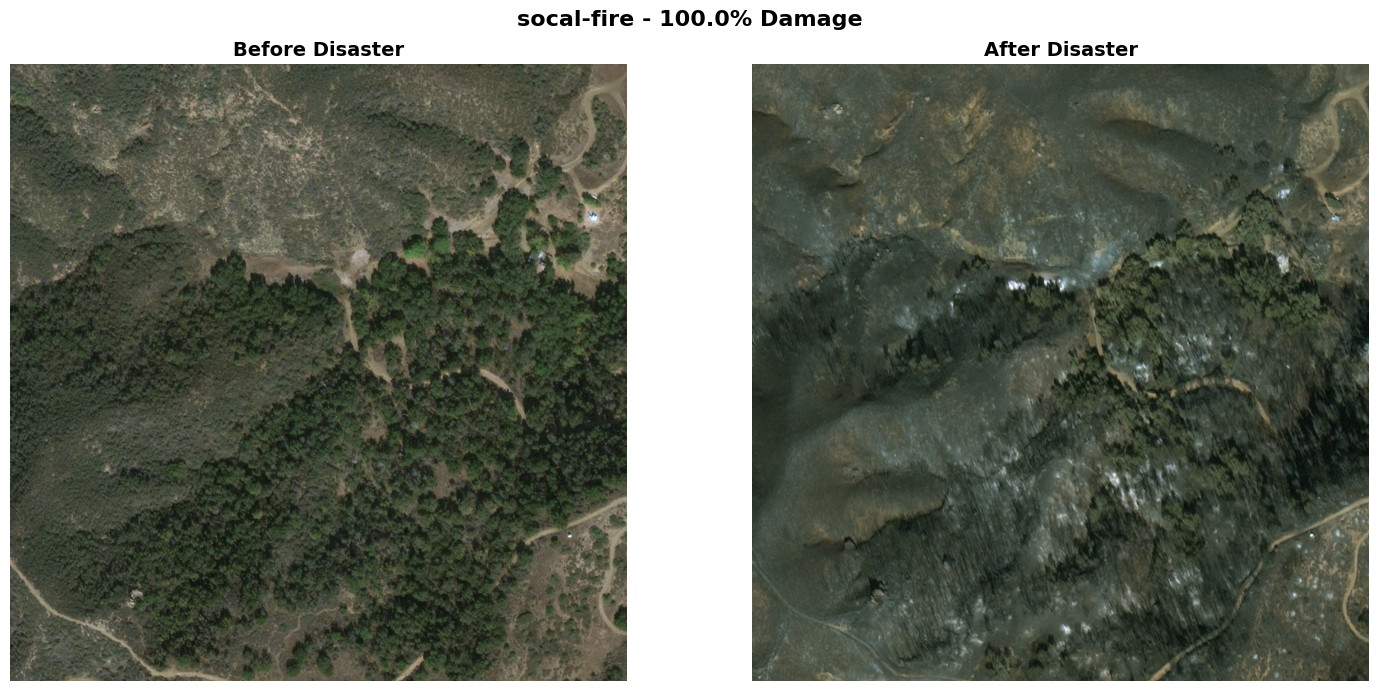

Image size: (1024, 1024)
Image mode: RGB
LABEL FILE STRUCTURE

Metadata:
  sensor: WORLDVIEW02
  provider_asset_type: WORLDVIEW02
  gsd: 2.5700748
  capture_date: 2018-11-14T18:42:58.000Z
  off_nadir_angle: 32.6742
  pan_resolution: 0.64383847
  sun_azimuth: 163.31218
  sun_elevation: 35.885086
  target_azimuth: 334.1289
  disaster: socal-fire
  disaster_type: fire
  catalog_id: 103001008513F200
  original_width: 1024
  original_height: 1024
  width: 1024
  height: 1024
  id: MjU3OTg3NQ.dmbvyD0UMO7SD_X-SvbV166fPSo
  img_name: socal-fire_00000221_post_disaster.png

Number of buildings: 3

Damage distribution:
  destroyed: 3 (100.0%)


In [ ]:
def find_damaged_examples(min_damage_percent=30):
    """
    Find examples where at least X% of buildings are damaged
    """
    damaged_examples = []
    
    # Sample 100 random images to check
    sample_pairs = random.sample(pairs, min(100, len(pairs)))
    
    for disaster_name, image_id, pre_path, post_path in sample_pairs:
        label_filename = f"{disaster_name}_{image_id}_post_disaster.json"
        label_path = os.path.join(LABELS_DIR, label_filename)
        
        if os.path.exists(label_path):
            label_data = load_labels(label_path)
            
            if 'features' in label_data and 'xy' in label_data['features']:
                buildings = label_data['features']['xy']
                
                # Count damaged buildings
                damaged = 0
                for building in buildings:
                    if 'properties' in building and 'subtype' in building['properties']:
                        subtype = building['properties']['subtype']
                        if subtype in ['minor-damage', 'major-damage', 'destroyed']:
                            damaged += 1
                
                if len(buildings) > 0:
                    damage_percent = (damaged / len(buildings)) * 100
                    if damage_percent >= min_damage_percent:
                        damaged_examples.append((disaster_name, image_id, pre_path, post_path, damage_percent))
    
    return damaged_examples

# Find heavily damaged areas
print("Searching for heavily damaged areas...")
damaged = find_damaged_examples(min_damage_percent=50)

if damaged:
    # Sort by damage percentage
    damaged.sort(key=lambda x: x[4], reverse=True)
    
    print(f"Found {len(damaged)} examples with 50%+ damage")
    print("\nShowing the most damaged area:")
    
    disaster_name, image_id, pre_path, post_path, damage_pct = damaged[0]
    print(f"{disaster_name} - {damage_pct:.1f}% buildings damaged")
    
    visualize_image_pair(pre_path, post_path, title=f"{disaster_name} - {damage_pct:.1f}% Damage")
    
    # Show label info
    label_filename = f"{disaster_name}_{image_id}_post_disaster.json"
    label_path = os.path.join(LABELS_DIR, label_filename)
    label_data = load_labels(label_path)
    print_label_info(label_data)
else:
    print("No heavily damaged examples found in sample")